<center><h1>A notebook used for results analysis</h1></center>

# Imports

The libraries needed to load the models and evaluate them

In [1]:
import numpy as np

import torch
from torch.utils.data import DataLoader

import torchvision.transforms as transforms
from torch import nn
import torch.nn.functional as F

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import seaborn as sns 

import helper

# Constants 

Specified constants for loaded models

Moreover, the transforms for data are defined, along with the GPU initiation

In [2]:
HIDDEN_LAYER_FEATURES = [32, 64, 96]
BATCH_SIZE = 16

TF = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((300, 300)),
    transforms.Normalize((0.5,), (0.5,))
])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Functions 
A special function to compute the confusion matrix for a specified loader by a specified model

In [3]:
def compute_confusion_matrix(model, loader, device):
    y_true = []
    y_pred = []

    for k, (X, y) in tqdm(enumerate(loader), total=len(loader)):
        X, y = X.to(device), y.to(device)

        logits = model(X)
        predictions = (torch.sigmoid(logits) > 0.5).sum(dim=1)

        y_true.extend(y.cpu().data.numpy())
        y_pred.extend(predictions.cpu().data.numpy())
    
    return confusion_matrix(y_true, y_pred)

A function to plot the computed matrix

In [4]:
def plot_confusion_matrix(matrix, save=False, name=None):
    plt.subplots(figsize=(10, 10))
    sns.heatmap(matrix, annot=False, cmap=sns.color_palette("mako", as_cmap=True), cbar=False, square=True, vmax=30, vmin=0, robust=True)

    if save:
        plt.savefig(f"figures/conf_matrix_{name}.png")

    plt.show()

A special function to evaluate the regression model and plot the scatter plot of predictions

In [5]:
def evaluate_and_plot(model, loader, device, save=False, name=None):
    model.eval()  
    y_true = []
    y_pred = []

    with torch.no_grad(): 
        for X, y in tqdm(loader, total=len(loader)):
            X, y = X.to(device), y.to(device)

            predictions = model(X)

            y_true_np_b = y.cpu().detach().numpy().flatten()
            y_pred_np_b = predictions.cpu().detach().numpy().flatten()

            y_true.extend(y_true_np_b)
            y_pred.extend(y_pred_np_b)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    plt.figure(figsize=(12, 6))
    
    plt.scatter(y_true, y_pred, alpha=0.7, marker='x', color="black")
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], color="red", linestyle="dashed")
    plt.grid()
    
    if save:
        plt.savefig(f'figures/scatter_{name}.png')
    
    plt.show()

# Model 

In [6]:
class CNN(nn.Module):
    def __init__(self, output_shape: int):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, HIDDEN_LAYER_FEATURES[0], 3, padding=1)
        self.conv2 = nn.Conv2d(HIDDEN_LAYER_FEATURES[0], HIDDEN_LAYER_FEATURES[1], 3, padding=1)
        self.conv3 = nn.Conv2d(HIDDEN_LAYER_FEATURES[1], HIDDEN_LAYER_FEATURES[2], 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.aa_pool = nn.AdaptiveAvgPool2d((3, 3))
        self.dropout = nn.Dropout(0.1)
        self.fc1 = nn.Linear(HIDDEN_LAYER_FEATURES[2] * 3 * 3 , 256)
        self.fc2 = nn.Linear(256, output_shape) 

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.aa_pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(self.dropout(x)))
        x = self.fc2(x)
        return x

# Classification

## 10x dataset

Initialization of dataset, model name and the amount of classes

In [7]:
DATASET_NAME_10 = '10x-r-10'
MODEL_NAME_10 = '10x-r10-clf-100e-s_state_dict'
CLASSES_10 = 94

Loading the model from the file and putting it to the evaluation mode

In [8]:
model_10 = CNN(output_shape=CLASSES_10).to(DEVICE)
model_10.load_state_dict(torch.load(f'models/{MODEL_NAME_10}.pth'))
model_10.eval()

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (aa_pool): AdaptiveAvgPool2d(output_size=(3, 3))
  (dropout): Dropout(p=0.1, inplace=False)
  (fc1): Linear(in_features=864, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=94, bias=True)
)

Loading the dataset form the file

In [9]:
dataset_10 = helper.load_dataset(path=f'datasets/{DATASET_NAME_10}.pth', transform=TF)

In [10]:
print(len(dataset_10))

14472


Train-Test Split

In [11]:
train_dataset_10, test_dataset_10 = helper.split(dataset_10, test_size=0.2)

train_loader_10 = DataLoader(train_dataset_10, batch_size=BATCH_SIZE, shuffle=True)
test_loader_10 = DataLoader(test_dataset_10, batch_size=BATCH_SIZE, shuffle=False)

In [12]:
print(len(train_dataset_10), len(test_dataset_10))

11577 2895


### Confusion matrix for test set

In [13]:
conf_10 = compute_confusion_matrix(model_10, test_loader_10, device=DEVICE)

  0%|          | 0/181 [00:00<?, ?it/s]

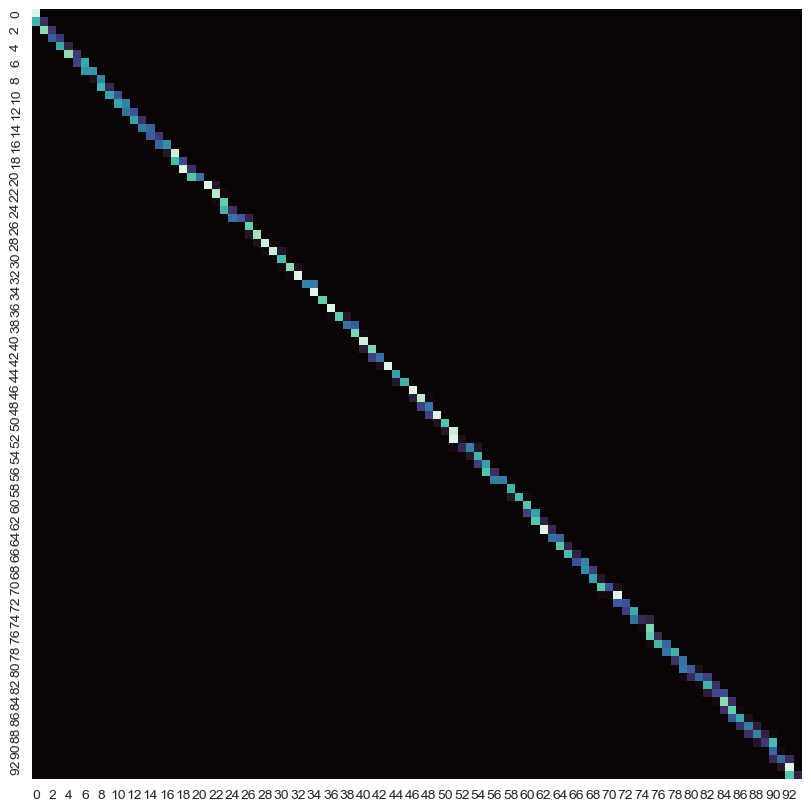

In [14]:
plot_confusion_matrix(conf_10, save=True, name="10x-r-10-test")

## 20x dataset

Same procedure of loading the model and loading the data

In [15]:
DATASET_NAME_20 = '20x-r-5'
MODEL_NAME_20 = '20x-r5-clf-100e-s_state_dict'
CLASSES_20 = 96

In [16]:
model_20 = CNN(output_shape=CLASSES_20).to(DEVICE)
model_20.load_state_dict(torch.load(f'models/{MODEL_NAME_20}.pth'))
model_20.eval()

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (aa_pool): AdaptiveAvgPool2d(output_size=(3, 3))
  (dropout): Dropout(p=0.1, inplace=False)
  (fc1): Linear(in_features=864, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=96, bias=True)
)

In [17]:
dataset_20 = helper.load_dataset(path=f'datasets/{DATASET_NAME_20}.pth', transform=TF)

In [18]:
print(len(dataset_20))

14472


In [19]:
train_dataset_20, test_dataset_20 = helper.split(dataset_20, test_size=0.2)

train_loader_20 = DataLoader(train_dataset_20, batch_size=BATCH_SIZE, shuffle=True)
test_loader_20 = DataLoader(test_dataset_20, batch_size=BATCH_SIZE, shuffle=False)

In [20]:
print(len(train_dataset_20), len(test_dataset_20))

11577 2895


### Confusion matrix for test set

In [21]:
conf_20 = compute_confusion_matrix(model_20, test_loader_20, device=DEVICE)

  0%|          | 0/181 [00:00<?, ?it/s]

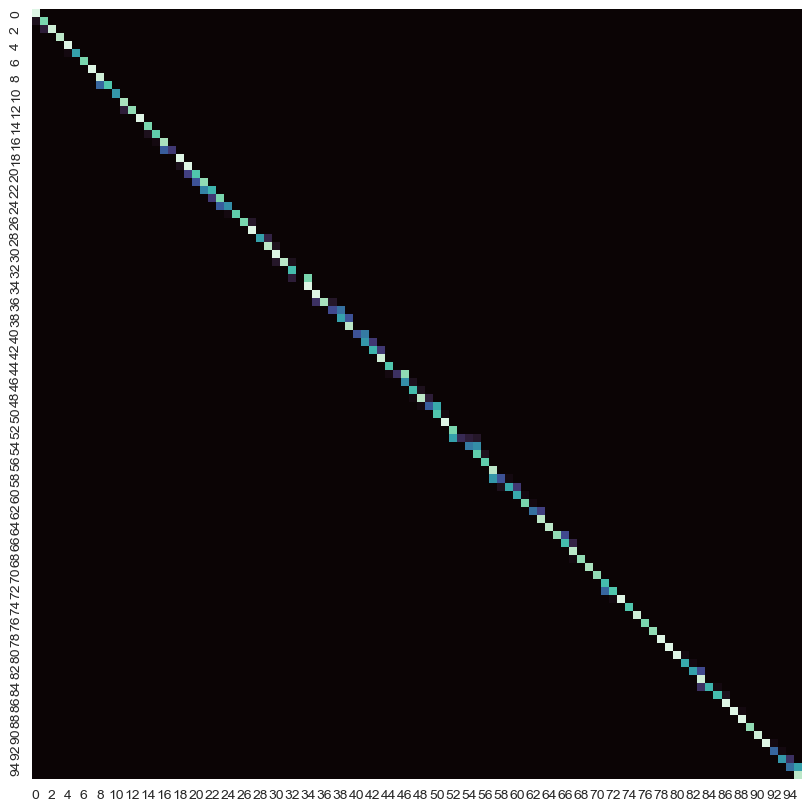

In [22]:
plot_confusion_matrix(conf_20, save=True, name="20x-r-5-test")

## all13 dataset

In [23]:
DATASET_NAME_ALL = 'all13-r-45'
MODEL_NAME_ALL = 'all13-r-45-100e-s_state_dict'
CLASSES_ALL = 98

In [24]:
model_all = CNN(output_shape=CLASSES_ALL).to(DEVICE)
model_all.load_state_dict(torch.load(f'models/{MODEL_NAME_ALL}.pth'))
model_all.eval()

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (aa_pool): AdaptiveAvgPool2d(output_size=(3, 3))
  (dropout): Dropout(p=0.1, inplace=False)
  (fc1): Linear(in_features=864, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=98, bias=True)
)

In [25]:
dataset_all = helper.load_dataset(path=f'datasets/{DATASET_NAME_ALL}.pth', transform=TF)

In [26]:
print(len(dataset_all))

17304


In [27]:
train_dataset_all, test_dataset_all = helper.split(dataset_all, test_size=0.2)

train_loader_all = DataLoader(train_dataset_all, batch_size=BATCH_SIZE, shuffle=True)
test_loader_all = DataLoader(test_dataset_all, batch_size=BATCH_SIZE, shuffle=False)

In [28]:
print(len(train_dataset_all), len(test_dataset_all))

13843 3461


### Confusion matrix for test set

In [29]:
conf_all = compute_confusion_matrix(model_all, test_loader_all, device=DEVICE)

  0%|          | 0/217 [00:00<?, ?it/s]

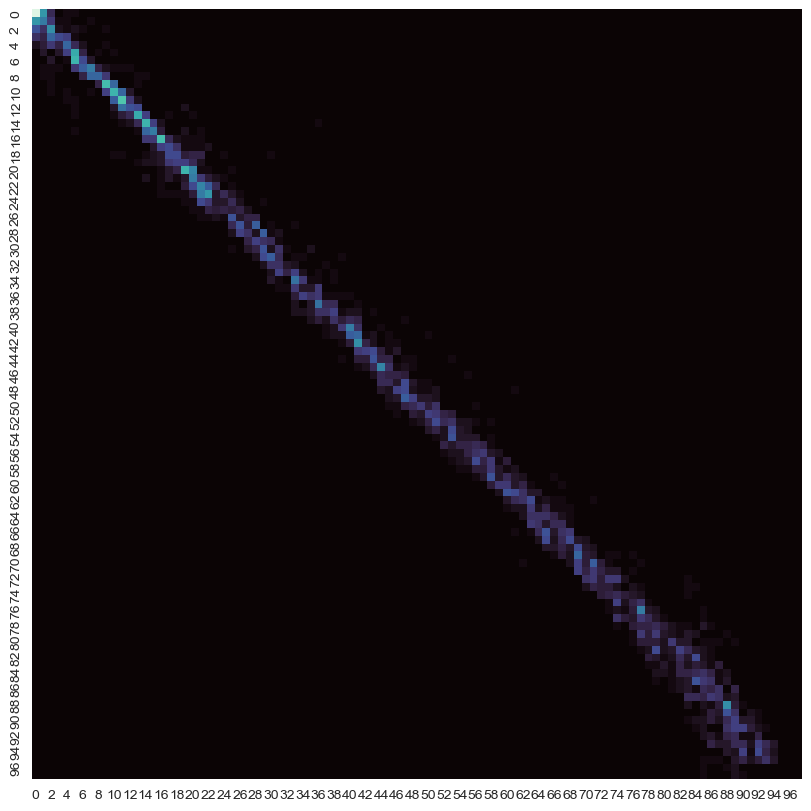

In [30]:
plot_confusion_matrix(conf_all, save=True, name="all13-r-45-test")

# Regression model

In [31]:
DATASET_NAME_ALL_REG = 'all13-reg'
MODEL_NAME_ALL_REG = 'all13-reg_state_dict'

In [32]:
model_all_reg = CNN(output_shape=1).to(DEVICE)
model_all_reg.load_state_dict(torch.load(f'models/{MODEL_NAME_ALL_REG}.pth'))
model_all_reg.eval()

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (aa_pool): AdaptiveAvgPool2d(output_size=(3, 3))
  (dropout): Dropout(p=0.1, inplace=False)
  (fc1): Linear(in_features=864, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=1, bias=True)
)

In [33]:
dataset_all_reg = helper.load_dataset(path=f'datasets/{DATASET_NAME_ALL_REG}.pth', transform=TF, floatlabels=True)

In [34]:
print(len(dataset_all_reg))

44013


In [35]:
train_dataset_all_reg, test_dataset_all_reg = helper.split(dataset_all_reg, test_size=0.2)

train_loader_all_reg = DataLoader(train_dataset_all_reg, batch_size=BATCH_SIZE, shuffle=True)
test_loader_all_reg = DataLoader(test_dataset_all_reg, batch_size=BATCH_SIZE, shuffle=False)

In [36]:
print(len(train_dataset_all_reg), len(test_dataset_all_reg))

35210 8803


## A scatter plot for regression

  0%|          | 0/551 [00:00<?, ?it/s]

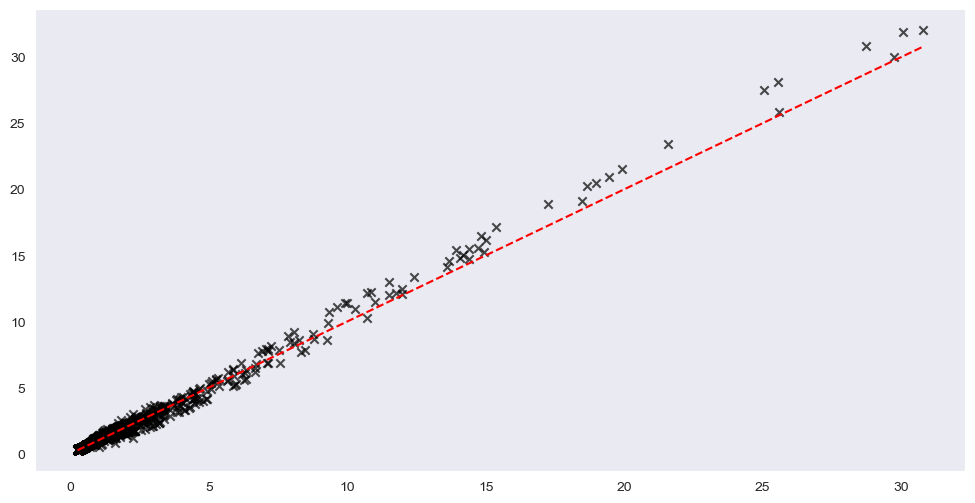

In [37]:
evaluate_and_plot(model_all_reg, test_loader_all_reg, DEVICE, save=True, name="all13-reg-test")